In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 03. 線形モデル — 直線・正則化・ロジスティック回帰

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- 最小二乗 (OLS) が「残差二乗和を最小化する直線」であること
- 多項式で複雑さを上げると過学習すること、**正則化** がそれを抑えること
- **Ridge(L2)** は係数を縮め、**Lasso(L1)** は一部を 0 にして特徴選択すること
- **ロジスティック回帰** は線形な対数オッズで確率を出す分類器であること
- 標準化した係数で「どの特徴がどちら向きに効くか」を読むこと

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, metrics
from ml_textbook.interpretation import coefficient_table

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. 最小二乗 (OLS) の直感

線形回帰は $\hat y = w^\top x + b$ という直線(超平面)を当てます。学習は **残差二乗和** を最小化:

$$
\min_{w,b}\; \sum_{i=1}^{n}\big(y_i - (w^\top x_i + b)\big)^2
$$

- $w$: 各特徴の傾き(係数)、$b$: 切片
- 二乗するので、大きく外した点ほど強くペナルティ

Diabetes データの 1 特徴(BMI)で、当てはめた直線と残差を見ます。

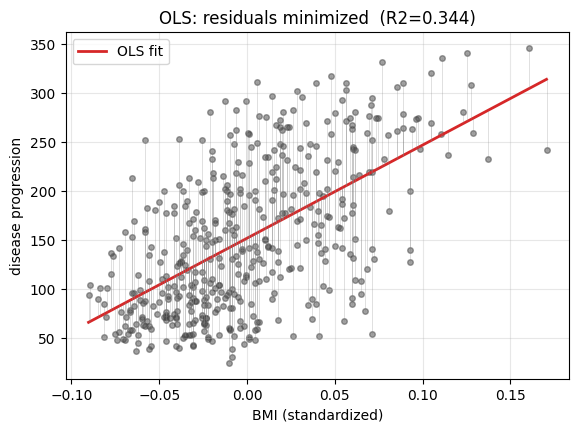

In [3]:
from sklearn.linear_model import LinearRegression

db = datasets.load_diabetes_dataset()
bmi = db.data[["bmi"]].to_numpy()
target = db.target.to_numpy()
ols = LinearRegression().fit(bmi, target)
pred = ols.predict(bmi)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(bmi, target, s=16, alpha=0.5, color="#444")
order = np.argsort(bmi.ravel())
ax.plot(bmi.ravel()[order], pred[order], color="#d62728", lw=2, label="OLS fit")
ax.vlines(bmi.ravel(), np.minimum(target, pred), np.maximum(target, pred), color="gray", alpha=0.25, lw=0.7)
ax.set_xlabel("BMI (standardized)"); ax.set_ylabel("disease progression")
ax.set_title(f"OLS: residuals minimized  (R2={metrics.r2_score(target, pred):.3f})")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## 2. 多項式回帰と過学習

特徴を多項式に拡張すると曲線も引けますが、次数を上げすぎるとノイズに食いつきます(過学習)。
下の Plotly スライダー(静的 HTML でも動く)で、次数を上げると **訓練 RMSE は下がるのにテスト RMSE が上がる** 様子を見てください。

In [4]:
x_poly, y_poly = datasets.make_polynomial_dataset(n=70, degree=3, noise=0.6, seed=0)
plotting.plotly_model_complexity(x_poly, y_poly, degrees=range(1, 14)).show()

## 3. 正則化 — 係数の大きさにペナルティ

過学習を抑える王道が **正則化**: 損失に「係数の大きさ」の罰則を足します。

$$
\underbrace{\sum_i (y_i - w^\top x_i)^2}_{\text{あてはまり}} \;+\; \alpha \underbrace{\lVert w \rVert}_{\text{罰則}}
$$

- **Ridge (L2)**: 罰則 $\alpha \sum_j w_j^2$。係数を 0 に近づけるが 0 にはしない。
- **Lasso (L1)**: 罰則 $\alpha \sum_j |w_j|$。一部の係数を **ちょうど 0** にする(=特徴選択)。
- $\alpha$ を上げるほど罰則が強く、係数は縮む。

> 注意: 正則化はスケールに敏感。**標準化してから** かける。

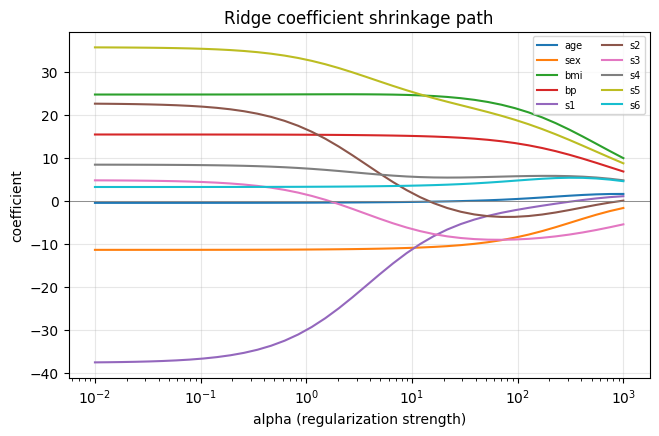

In [5]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

Xd = StandardScaler().fit_transform(db.data.to_numpy())
yd = db.target.to_numpy()
names = list(db.feature_names)

alphas = np.logspace(-2, 3, 40)
ridge_coefs = np.array([Ridge(alpha=a).fit(Xd, yd).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for j, name in enumerate(names):
    ax.plot(alphas, ridge_coefs[:, j], label=name)
ax.set_xscale("log"); ax.set_xlabel("alpha (regularization strength)"); ax.set_ylabel("coefficient")
ax.set_title("Ridge coefficient shrinkage path"); ax.axhline(0, color="gray", lw=0.6)
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3); plt.show()

### インタラクティブ: 正則化の強さ(Ridge)

$\alpha$ を動かすと係数が一斉に 0 へ縮みます。テスト RMSE が最小になる中間の $\alpha$ が狙い目です。

In [6]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.3, random_state=0)
slider_alphas = np.logspace(-2, 3, 24)

frames = []
for a in slider_alphas:
    m = Ridge(alpha=a).fit(Xtr, ytr)
    rmse = float(np.sqrt(np.mean((m.predict(Xte) - yte) ** 2)))
    frames.append(go.Frame(name=f"{a:.3g}",
                           data=[go.Bar(x=names, y=m.coef_, marker_color="#1f77b4")],
                           layout={"title": f"alpha = {a:.3g}   test RMSE = {rmse:.1f}"}))
fig = go.Figure(data=frames[0].data, frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "alpha = "}}],
                  title=frames[0].layout.title.text, yaxis_title="coefficient",
                  width=760, height=460, margin={"l": 50, "r": 20, "t": 60, "b": 80})
fig.show()

## 4. Lasso は特徴を選ぶ

同じ強さでも、Lasso は弱い特徴の係数を **ちょうど 0** にします。Ridge は全部残して縮めるだけ。

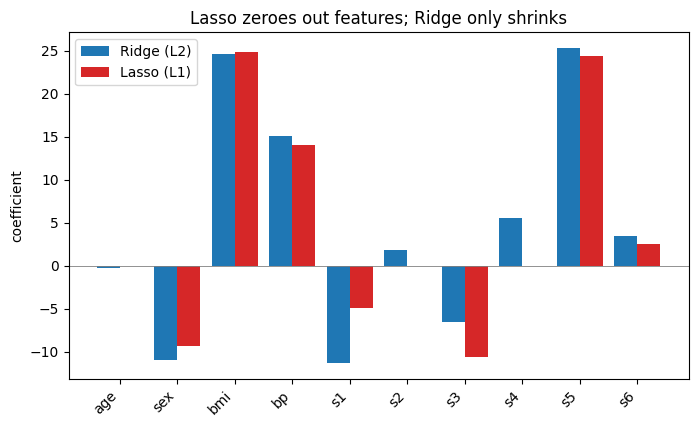

Lasso coefficients exactly zero: ['age', 's2', 's4']


In [7]:
ridge = Ridge(alpha=10.0).fit(Xd, yd)
lasso = Lasso(alpha=1.0, max_iter=10000).fit(Xd, yd)

x = np.arange(len(names)); w = 0.4
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, ridge.coef_, width=w, label="Ridge (L2)", color="#1f77b4")
ax.bar(x + w/2, lasso.coef_, width=w, label="Lasso (L1)", color="#d62728")
ax.axhline(0, color="gray", lw=0.6); ax.set_xticks(x); ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylabel("coefficient"); ax.set_title("Lasso zeroes out features; Ridge only shrinks")
ax.legend(); plt.show()
print("Lasso coefficients exactly zero:", [names[j] for j in np.where(np.abs(lasso.coef_) < 1e-8)[0]])

## 5. ロジスティック回帰 — 線形な分類器

分類では、線形な値 $z = w^\top x + b$ を **シグモイド** で確率に変換します:

$$
\hat p = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad
\text{損失} = -\frac{1}{n}\sum_i \big[y_i \log \hat p_i + (1-y_i)\log(1-\hat p_i)\big]
$$

これが **ログ損失(交差エントロピー)**。境界 $\hat p = 0.5$ は $z=0$、すなわち直線になります。

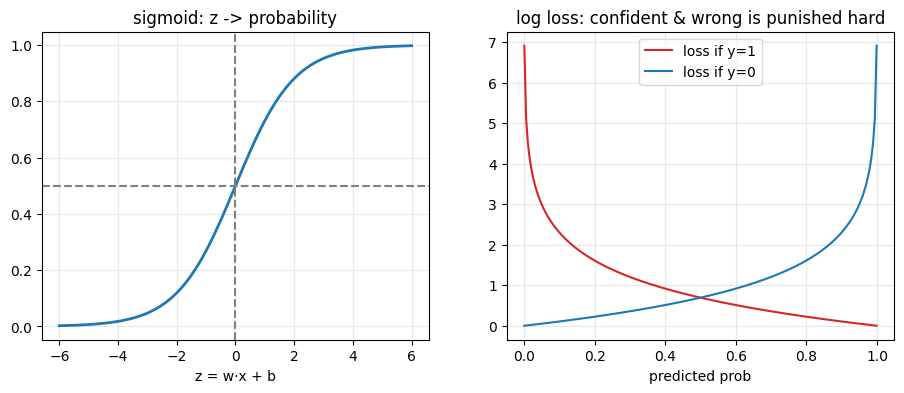

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
z = np.linspace(-6, 6, 200)
axes[0].plot(z, 1 / (1 + np.exp(-z)), lw=2, color="#1f77b4")
axes[0].axhline(0.5, color="gray", ls="--"); axes[0].axvline(0, color="gray", ls="--")
axes[0].set_title("sigmoid: z -> probability"); axes[0].set_xlabel("z = w·x + b"); axes[0].grid(alpha=0.3)
p = np.linspace(1e-3, 1 - 1e-3, 200)
axes[1].plot(p, -np.log(p), label="loss if y=1", color="#d62728")
axes[1].plot(p, -np.log(1 - p), label="loss if y=0", color="#1f77b4")
axes[1].set_title("log loss: confident & wrong is punished hard"); axes[1].set_xlabel("predicted prob")
axes[1].legend(); axes[1].grid(alpha=0.3); plt.show()

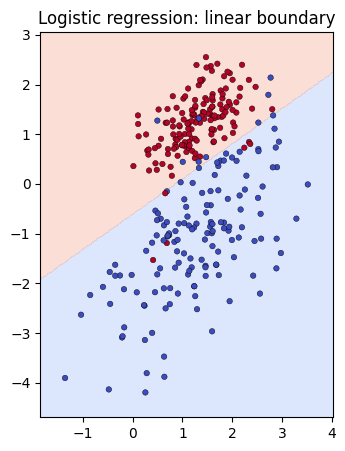

In [9]:
from sklearn.linear_model import LogisticRegression

Xc, yc = datasets.make_classification_dataset(n=300, n_features=2, class_sep=1.2, seed=0)
clf = LogisticRegression().fit(Xc, yc)
ax = plotting.plot_decision_boundary(clf.predict, Xc, yc, title="Logistic regression: linear boundary")
ax.set_aspect("equal"); plt.show()

## 6. 正則化の強さ `C` と汎化

ロジスティック回帰の正則化は `C`(= 1/α の逆数)。**C が小さい = 強い正則化**。
検証曲線で、強すぎると未学習・弱すぎると過学習になる U 字を確認します。

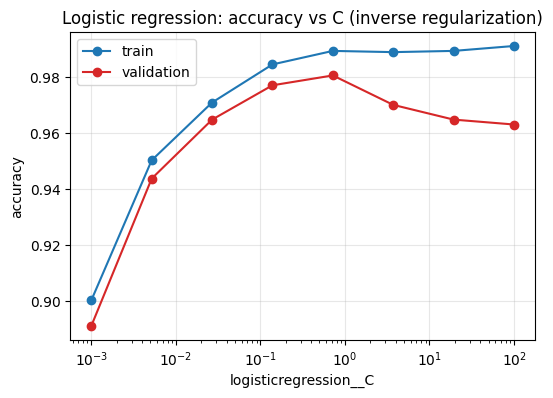

In [10]:
bc = datasets.load_breast_cancer_dataset()
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
ax = plotting.plot_validation_curve(
    pipe, bc.data, bc.target,
    param_name="logisticregression__C", param_range=np.logspace(-3, 2, 8), cv=5, scoring="accuracy", logx=True,
)
ax.set_title("Logistic regression: accuracy vs C (inverse regularization)")
plt.show()

## 7. 係数の解釈

特徴を **標準化** してから学習すると、係数の大きさを直接比べられます。
正の係数は「その特徴が大きいほど陽性(ここでは悪性)に傾く」ことを意味します。

Top features pushing the prediction (|coefficient|):
             feature  coefficient  abs_coefficient
       worst texture    -1.320556         1.320556
        radius error    -1.289261         1.289261
        worst radius    -1.026586         1.026586
          area error    -0.998861         0.998861
          worst area    -0.994671         0.994671
 mean concave points    -0.962849         0.962849
worst concave points    -0.925175         0.925175
      worst symmetry    -0.888711         0.888711


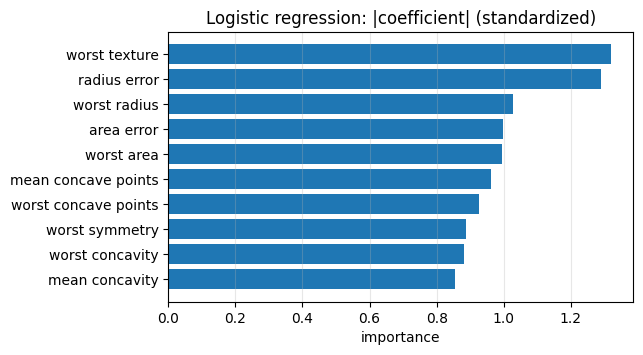

In [11]:
log_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(bc.data, bc.target)
coef = log_pipe.named_steps["logisticregression"]
table = coefficient_table(coef, bc.feature_names)
print("Top features pushing the prediction (|coefficient|):")
print(table.head(8).to_string(index=False))
ax = plotting.plot_feature_importance(table["feature"], table["abs_coefficient"], top=10,
                                      title="Logistic regression: |coefficient| (standardized)")
plt.show()

## 8. まとめ

- OLS は残差二乗和を最小化する直線。多項式で曲げられるが過学習しやすい。
- **正則化**(Ridge/Lasso/ElasticNet)は係数の大きさを罰して過学習を抑える。**標準化してから**かける。
- Ridge は縮めるだけ、**Lasso は 0 にして特徴選択**。ElasticNet は両者の混合。
- ロジスティック回帰は線形な対数オッズ + シグモイドで確率を出し、ログ損失で学習する。境界は直線。
- 標準化した係数は「どの特徴がどちら向きに効くか」を読む手がかり(因果ではない → 09 章)。

## 9. Exercises

1. Ridge の $\alpha$ スライダーで、テスト RMSE が最小になる $\alpha$ を読み取り、`RidgeCV` の結果と比べよ。
2. Lasso の `alpha` を 0.1 / 1 / 5 と変え、0 になる特徴がどう増えるか観察せよ。
3. 多項式の次数スライダーで、`noise` を 0.2 と 1.0 にすると最適次数がどう変わるか。
4. ロジスティック回帰の `C` を 0.001 と 100 にして決定境界の傾きの違いを比べよ。
5. (発展)Diabetes で OLS / Ridge / Lasso の 5-fold CV の R2 を比較し、どれが最良か述べよ。

## 10. Common Mistakes

- **標準化せずに正則化する。** スケールの大きい特徴だけ過剰に罰せられる。
- **生の係数の大小で重要度を語る。** 標準化していないと単位依存で無意味。
- **多項式の次数を上げれば良いと思う。** 検証で最適次数を選ぶ(交差検証 → 04 章)。
- **係数の符号を因果と解釈する。** 相関であって因果ではない(09 章)。

## 11. Advanced Notes

**Ridge の閉形式。** Ridge には解析解 $\hat w = (X^\top X + \alpha I)^{-1}X^\top y$ がある。
$\alpha I$ を足すことで $X^\top X$ が常に正則になり、多重共線性(相関の強い特徴)でも安定する。
これが「Lasso は選択、Ridge は安定化」と言われる理由の一つ。次章のキャップストーン的視点では、
**勾配降下を十分回すと OLS 解に収束**し、正則化は事前分布(ベイズ)とも対応する(姉妹本参照)。